In [1]:
#analysis in multiple parameter sets for bifurcation models with sleep-wake dynamics  FigS11

import os
import sys

from scipy.signal import find_peaks
from scipy.signal import periodogram
from scipy import signal
import scipy

import gc
import traceback

 #make sh file
import matplotlib.pyplot as plt
from vistats import annotate_brackets

import numpy as np
import shutil
import math
import pandas as pd


sys.path.append('../')
sys.path.append('../anmodel')
import matplotlib.pyplot as plt

import anmodel

import pickle


fs = 20
fs_l = 15

OK
OK


In [2]:
def eva_pv(p):
    if p<0.05 and p>=0.01:
        print("p<0.05, *")
        pstr="*"
    elif p<0.01 and p>=0.001:
        print("p<0.01, **")
        pstr="**"
    elif p<0.001 and p>= 0.0001:
        print("p<0.001, ***")
        pstr="***"
    elif p<0.0001:
        print("p<0.0001, ****")
        pstr="****"
    else:
        print("p>=0.05, ns")
        pstr="ns"
    return pstr

def check_osci(sp):
    ntraverse =0
    for i in range(len(sp)-1):
        if (sp[i]-0.5) * (sp[i+1]-0.5) < 0:
            ntraverse += 1
    print("n_traverse", ntraverse)
    if ntraverse >=2:
        return 1
    else:
        return 0
    
def check_convergence(v,   epsilon=1.0):
    """
    Judge if each state of a substrate is convergent.
    
    Parameters
    --------------
    v : array
    A sequence of a state of a substrate.
    trange : int
    The time the integration was done.
    epsilon : scalar
    A threshold for the judge.
    
    Returns
    ----------
    1 if not convergence.
    """
    
    rang =0# len(v)
    
    # check convergence
#     vstd = np.std(v[-rang:])
    vstd = np.std(v[int(rang/5):])
    
    diffstd = np.std(np.diff(v[int(rang/5):]))
    print(diffstd)
    if diffstd < epsilon:
        return(3)
    elif vstd < epsilon:
        return(0)
    else:
        return(1) # not convergence

In [21]:
#evaluate pearson corr
#update by a

rdir = "../AN_network/"

adp_li = [0.45, 0.65, 0.85] #SP -> K  
bdp_li = [20.0, 40.0, 60.0] # curve  30.0
tau_k_li = [8000,  10000, 15000, 20000, 25000, 30000]

I_op = -20.0
bdp2_op = 0.25

model_pre = "AN"
op = "_net_aup"
bifur = "_nmdar"
model_op= op+"_th0"#"_exps_slim0_klim0_ca"


# ex = -1.0
cv_th = 1.0
max_con =8.0
ex = -1.0
con_log = True

NE = 64
Ip = 20
NI = int(NE*Ip/(100-Ip))
con_M = 1.0
con_M_in = 1.0
con_ex_ex = 0.01
con_ex_in =0.01
con_in_ex = 0.01
con_in_in = 0.01
th_sp = 0.3

Sp_ini = 0.9
K_ini = 0.1
z_ini = 0.0

corr_th=0.7

swr=[0.7, 1.3]

if con_log==False:
    model_name = model_pre + model_op+bifur

else:
    model_name = model_pre+ model_op + bifur
    
c=0

pre = "NE{}_NI{}/conM{}_SD{}_conMin{}_inSD{}/Spini{}_Kini{}_zini{}".format(NE, NI,con_M, con_ex_ex,con_M_in, con_in_in,  Sp_ini, K_ini, z_ini)
cadyn_dir = rdir + "/cadyn_dir_lrsw/{}/".format(model_name)


corr_com = "r"


corr_selected =[]
corr_vals = []


dates_i  = os.listdir(cadyn_dir)

dates_i = ["param_2023_4_26_0_2","param_2023_4_20_0_12","param_2023_4_20_0_15","param_2023_6_17_3_8","param_2023_7_17_7_13",
           "param_2023_7_1_3_10","param_2023_7_21_0_7","param_2023_6_1_3_13","param_2023_6_9_3_1","param_2023_5_3_0_4",
        "param_2023_12_7_4_6", "param_2023_12_7_4_9","param_2023_8_9_0_5", 
           "param_2023_7_23_7_0", "param_2023_6_3_0_11" ]
# dates_i = ["param_2023_4_26_0_2","param_2023_4_20_0_12","param_2023_4_20_0_15","param_2023_6_17_3_8","param_2023_7_17_7_13",
#            "param_2023_7_1_3_10","param_2023_7_21_0_7","param_2023_6_1_3_13","param_2023_6_9_3_1","param_2023_5_3_0_4",
#            "param_2023_7_17_2_12", "param_2023_12_7_4_6", "param_2023_12_7_4_9","param_2023_8_9_0_5", 
#            "param_2023_7_23_7_0", "param_2023_6_3_0_11","param_2023_7_24_1_1" ,
#           "param_2023_5_5_0_13", "param_2023_5_3_0_1", "param_2023_7_19_7_8","param_2023_7_11_7_15", 
#            "param_2023_7_11_7_4", "param_2023_8_4_1_3","param_2023_6_1_3_3", "param_2023_4_24_0_12", "param_2023_7_4_5_14",
#      ]



date_a_r_max_li=[]
date_a_a_max_li=[]
date_a_r_max_paths=[]
date_a_a_max_paths=[]
dates_a_r=[]
dates_a_a=[]

for date_i in dates_i:
    date_i2 = date_i.replace("param_", "")
#     if date_i2!="2023_4_26_0_2":
#         continue
    
    date_r_li =[]
    date_a_li =[]
    date_pathr_li=[]
    date_patha_li=[]

    exps  = os.listdir(cadyn_dir+date_i+"/"+pre)
    for exp in exps:
        if not os.path.exists(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"):
                continue
        adp = float(exp.split("_")[2])
        bdp = float(exp.split("_")[3])
        bdp2=float(exp.split("_")[5])
        print("adp", adp)
        
        if not adp in adp_li or not bdp in bdp_li or bdp2!=bdp2_op:
            continue
        
        taus = os.listdir(cadyn_dir+date_i+"/"+pre+"/"+exp+"/")
        for tau in taus:
                if not os.path.exists(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"):
                    continue
                tauk = int(tau.split("_")[1][4:])
                print("tauk", tauk)
                if not tauk in tau_k_li:
                    continue
                w_nos= os.listdir(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/")
                for w_no in w_nos:
                    if not os.path.exists(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"):
                        continue
                    I = float(w_no.split("_")[2][1:])
                    print("I", I)
                    if I!=I_op:
                        continue
                    Ts= os.listdir(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/")
                    for T in Ts:
                        if not os.path.exists(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/"):
                                continue
                        exss = os.listdir(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/")
                        for exs in exss:
                            if not os.path.exists(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"):
                                continue
                            lrs = os.listdir(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/")
                            for lr in lrs:
#                                 maxcons = os.listdir(cadyn_dir+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+lr+"/")
                                if not os.path.exists(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+lr+"/"):
                                    continue
                                maxcons = os.listdir(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+lr+"/")
                                for maxcon in maxcons:
                                    if not os.path.exists(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+lr+"/"+maxcon+"/"):
                                        continue
                                    savefs = os.listdir(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+lr+"/"+maxcon+"/")
                                
                                    corr_r_li = []
                                    corr_a_li = []
                                    paths =[]
                                    
                                    sw_exist_flag=0
                                    sw_out_flag=0
                                    for savef in savefs:
                                        if ".xlsx" in savef:
                                            df_sw = pd.read_excel(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+lr+"/"+maxcon+"/"+savef, engine="openpyxl", index_col=0)
#                                             print(swT)
                                            sw_ratio = df_sw["sw_ratio"].iloc[0]
#                                             print("sw_ratio", sw_ratio)
                                            sw_exist_flag=1
                                            
                                            
                                            if sw_ratio < swr[0] or sw_ratio > swr[1] or math.isnan(sw_ratio):
#                                                 print("sw_ratio out of range")
                                                sw_out_flag=1
                                                
                                    if sw_exist_flag==0 or sw_out_flag==1:
                                        continue
                                    
                                    print("sw_ratio", sw_ratio)

                                    for savef in savefs:

                                        if "_corr_pros" in savef or "_corr_pros_m" in savef:
#                                             print(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+lr+"/"+maxcon+"/"+savef)

#                                                 if os.path.exists(cadyn_dir+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+lr+"/"+maxcon+"/"+savef):

                                            corr_np = np.genfromtxt(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+lr+"/"+maxcon+"/"+savef, delimiter=',', dtype=np.float64)
#                                             print(corr_np)
                                            r = corr_np[0]
                                            a = corr_np[2]
#                                             print(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+lr+"/"+maxcon+"/"+savef)
                                            print("r", r)
                                            print("a", a)
                                            corr_r_li.append(r)
                                            corr_a_li.append(a)
                                            paths.append(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+lr+"/"+maxcon+"/"+savef)

#                                                 if corr_com=="r":
                                    if len(corr_r_li)!=0:
                                        max_in_r=np.argmax(corr_r_li)
                                        max_r = corr_r_li[max_in_r]
                                        path_r = paths[max_in_r]
                                        date_r_li.append(max_r)
                                        date_pathr_li.append(path_r)

                                    if len(corr_a_li)!=0:
                                        max_in_a=np.argmax(corr_a_li)
                                        max_a = corr_a_li[max_in_a]
                                        path_a = paths[max_in_a]
                                        date_a_li.append(max_a)
                                        date_patha_li.append(path_a)
    if len(date_r_li)!=0:   
        max_r_in2 = np.argmax(date_r_li)
        dates_a_r.append(date_i2)
        date_a_r_max_li.append(date_r_li[max_r_in2])
        date_a_r_max_paths.append(date_pathr_li[max_r_in2])
        
    if len(date_a_li)!=0:
        max_a_in2 = np.argmax(date_a_li)
        dates_a_a.append(date_i2)
        date_a_a_max_li.append(date_a_li[max_a_in2])
        date_a_a_max_paths.append(date_patha_li[max_a_in2])
                
#                                                     if r > corr_th:
#                                                         corr_vals.append(r)
#                                                         corr_selected.append(cadyn_dir+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+savef)
#                                                 elif corr_com=="a":
#                                                     if a > corr_th:
#                                                         corr_vals.append(a)
#                                                         corr_selected.append(cadyn_dir+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+savef)

                                        
print("dates_a_r", dates_a_r)
print("date_a_r_max_li", date_a_r_max_li)
print(date_a_r_max_paths)


print("dates_a_a", dates_a_a)
print("date_a_a_max_li", date_a_a_max_li)
print(date_a_a_max_paths)


adp 0.8
adp 0.8
adp 0.8
adp 0.8
adp 0.8
adp 0.8
adp 0.8
adp 0.8
adp 0.8
adp 0.8
adp 0.8
adp 0.8
adp 0.8
adp 0.8
adp 0.8
adp 0.8
adp 0.8
adp 0.45
tauk 8000
I -20.0
sw_ratio 1.123595505617978
r 0.03474661967050031
a 0.2682619480113587
tauk 10000
I -20.0
sw_ratio 0.9731800766283525
r 0.08828839690981741
a 0.28712139846626555
tauk 15000
I -20.0
sw_ratio 1.090047393364929
r 0.6096946431183994
a 0.6663927615173105
tauk 20000
I -20.0
tauk 25000
I -20.0
tauk 30000
I -20.0
adp 0.45
tauk 8000
I -20.0
sw_ratio 1.182170542635659
r -0.03244250359813747
a 0.24160507047438376
tauk 10000
I -20.0
tauk 15000
I -20.0
tauk 20000
I -20.0
tauk 25000
I -20.0
tauk 30000
I -20.0
adp 0.45
tauk 8000
I -20.0
tauk 10000
I -20.0
tauk 15000
I -20.0
tauk 20000
I -20.0
tauk 25000
I -20.0
tauk 30000
I -20.0
adp 0.45
tauk 8000
I -20.0
tauk 10000
I -20.0
tauk 15000
I -20.0
tauk 20000
I -20.0
tauk 25000
I -20.0
tauk 30000
I -20.0
adp 0.45
tauk 8000
I -20.0
tauk 10000
I -20.0
tauk 15000
I -20.0
tauk 20000
I -20.0
tauk 2500

tauk 20000
I -20.0
tauk 8000
I -20.0
tauk 25000
I -20.0
tauk 30000
I -20.0
adp 0.85
tauk 10000
I -20.0
sw_ratio 0.9285714285714286
r 0.3037120195028537
a 0.42324336030024434
r 0.33922932527252914
a 0.31798268465599683
tauk 15000
I -20.0
tauk 20000
I -20.0
tauk 8000
I -20.0
tauk 25000
I -20.0
sw_ratio 0.9731800766283525
r 0.7071399551495859
a 0.2947080551319415
tauk 30000
I -20.0
adp 0.6
adp 0.6
adp 0.7
adp 0.6
adp 0.65
tauk 10000
I -20.0
sw_ratio 0.984
r 0.2810109161864065
a 0.34291128804183196
r 0.3698537391066729
a 0.3501431034688669
tauk 15000
I -20.0
tauk 20000
I -20.0
sw_ratio 1.12621359223301
r 0.5628822699051718
a 0.6834909687357309
r 0.6050628648318348
a 0.6435469109048726
tauk 8000
I -20.0
tauk 25000
I -20.0
sw_ratio 0.9683257918552036
r 0.6064979946798236
a 0.48613079968213463
tauk 30000
I -20.0
adp 0.45
tauk 15000
I -20.0
tauk 10000
I -20.0
tauk 20000
I -20.0
tauk 8000
I -20.0
sw_ratio 0.8354430379746836
r 0.28086226550076426
a 0.01732657017218538
tauk 25000
I -20.0
tauk 300

I -20.0
adp 0.85
tauk 20000
I -20.0
tauk 15000
I -20.0
tauk 10000
I -20.0
tauk 8000
I -20.0
tauk 25000
I -20.0
tauk 30000
I -20.0
adp 0.65
tauk 10000
I -20.0
tauk 12000
tauk 8000
I -20.0
sw_ratio 0.7536231884057971
r 0.33704166062714935
a -0.016842868818711505
r 0.34145565325730215
a -0.014560257553215382
sw_ratio 0.7668918918918919
r 0.38797324713033177
a 0.16062763106784633
tauk 15000
I -20.0
tauk 14000
tauk 20000
I -20.0
sw_ratio 0.7684563758389261
r 0.27582626749241396
a -0.2386774523366929
r 0.19558556537934677
a -0.3462844475777343
tauk 25000
I -20.0
tauk 30000
I -20.0
adp 0.45
tauk 10000
I -20.0
tauk 15000
I -20.0
tauk 20000
I -20.0
sw_ratio 0.7692307692307693
r 0.27249032960006053
a -0.21531827827934083
r 0.141957461242922
a -0.4025809095237425
tauk 8000
I -20.0
tauk 25000
I -20.0
tauk 30000
I -20.0
sw_ratio 0.7342342342342343
r 0.08928274408969931
a -0.5016318031567114
adp 0.65
adp 0.85
adp 0.85
tauk 20000
I -20.0
tauk 10000
I -20.0
tauk 8000
I -20.0
tauk 12000
tauk 15000
I -2

sw_ratio 1.149732620320856
r -0.34860243607593216
a -0.8689766526058798
adp 0.45
tauk 30000
I -20.0
sw_ratio 1.266666666666667
r -0.1689040135965197
a -0.8168937523999233
sw_ratio 0.9902912621359223
r -0.08004738532028831
a -0.7746341524379078
tauk 20000
I -20.0
sw_ratio 1.21608040201005
r -0.2984069064997064
a -0.8127222591178629
sw_ratio 1
r -0.24371164964198644
a -0.7659831003741204
tauk 10000
I -20.0
sw_ratio 0.8927335640138409
r -0.3557668646026268
a -0.7073755862394673
tauk 15000
I -20.0
sw_ratio 0.9105058365758755
r -0.3040007738331448
a -0.7822189258846842
adp 0.65
tauk 30000
I -20.0
sw_ratio 1.207446808510638
r -0.3004155922883595
a -0.8501863439283663
sw_ratio 0.9666666666666667
r -0.23953747579757645
a -0.8232104920541798
tauk 20000
I -20.0
sw_ratio 0.7943548387096774
r -0.40589729843632855
a -0.8280626341166666
sw_ratio 1.166023166023166
r -0.34299596234829044
a -0.8517005817445219
sw_ratio 0.9864253393665159
r -0.47592179704586374
a -0.840359878736876
tauk 10000
I -20.0
ta

adp 0.65
adp 0.65
tauk 20000
I -20.0
adp 0.65
tauk 20000
I -20.0
adp 0.45
tauk 10000
I -20.0
sw_ratio 0.8141263940520446
r 0.3297335990849262
a 0.26355367736494906
tauk 15000
I -20.0
tauk 20000
I -20.0
adp 0.85
tauk 15000
I -20.0
sw_ratio 0.8028169014084507
r 0.4939746569472685
a 0.11190063817565216
tauk 10000
I -20.0
tauk 20000
I -20.0
adp 0.65
tauk 20000
I -20.0
tauk 10000
I -20.0
sw_ratio 0.7154150197628458
r -0.18651774470697077
a -0.6574780862471336
tauk 15000
I -20.0
sw_ratio 0.7379310344827587
r 0.2661032829672837
a -0.3592536886600073
adp 0.45
tauk 15000
I -20.0
sw_ratio 0.75
r 0.42217424862352676
a 0.06074430413667507
tauk 10000
I -20.0
sw_ratio 0.7275985663082437
r 0.5086517312706719
a 0.24517098095914588
tauk 20000
I -20.0
adp 0.65
tauk 15000
I -20.0
tauk 10000
I -20.0
tauk 20000
I -20.0
sw_ratio 0.8461538461538461
r 0.3316417179224439
a -0.12254715113451621
adp 0.85
tauk 15000
I -20.0
sw_ratio 1.189189189189189
r -0.10147107828967177
a -0.26448734473175545
tauk 10000
I -20.

In [4]:
#update by r
rdir = "../AN_network/"

adp_li = [0.45, 0.65, 0.85] #SP -> K  
bdp_li = [20.0, 40.0, 60.0] # curve  30.0
tau_k_li = [8000,  10000, 15000, 20000, 25000, 30000]

I_op = -20.0
bdp2_op = 0.25

model_pre = "AN"
op = "_net_aup"
bifur = "_nmdar"
model_op= op+"_th0"#"_exps_slim0_klim0_ca"


# ex = -1.0
cv_th = 1.0
max_con =8.0
ex = -1.0
con_log = True

NE = 64
Ip = 20
NI = int(NE*Ip/(100-Ip))
con_M = 1.0
con_M_in = 1.0
con_ex_ex = 0.01
con_ex_in =0.01
con_in_ex = 0.01
con_in_in = 0.01
# T = 400000
# Tp = 5000
th_sp = 0.3
# offset = 0
# dt = 0.05
Sp_ini = 0.9
K_ini = 0.1
z_ini = 0.0

corr_th=0.7

swr=[0.7, 1.3]

if con_log==False:
    model_name = model_pre + model_op+bifur

else:
    model_name = model_pre+"_log"+ model_op + bifur
    

c=0

pre = "NE{}_NI{}/conM{}_SD{}_conMin{}_inSD{}/Spini{}_thsp{}_Kini{}_zini{}".format(NE, NI,con_M, con_ex_ex,con_M_in, con_in_in,  Sp_ini, th_sp, K_ini, z_ini)
cadyn_dir = rdir + "/cadyn_dir_lrsw/{}/".format(model_name)


corr_com = "r"

corr_selected =[]
corr_vals = []


dates_i  = os.listdir(cadyn_dir)

dates_i = ["param_2023_4_26_0_2","param_2023_4_20_0_12","param_2023_4_20_0_15","param_2023_6_17_3_8","param_2023_7_17_7_13",
           "param_2023_7_1_3_10","param_2023_7_21_0_7","param_2023_6_1_3_13","param_2023_6_9_3_1","param_2023_5_3_0_4",
        "param_2023_12_7_4_6", "param_2023_12_7_4_9","param_2023_8_9_0_5", 
           "param_2023_7_23_7_0", "param_2023_6_3_0_11" ]


date_r_r_max_li=[]
date_r_a_max_li=[]
date_r_r_max_paths=[]
date_r_a_max_paths=[]
dates_r_r=[]
dates_r_a=[]

for date_i in dates_i:
    date_i2 = date_i.replace("param_", "")
#     if date_i2!="2023_4_26_0_2":
#         continue
    
    date_r_li =[]
    date_a_li =[]
    date_pathr_li=[]
    date_patha_li=[]

    exps  = os.listdir(cadyn_dir+date_i+"/"+pre)
    for exp in exps:
        if not os.path.exists(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"):
                continue
        adp = float(exp.split("_")[2])
        bdp = float(exp.split("_")[3])
        bdp2=float(exp.split("_")[5])
        print("adp", adp)
        
        if not adp in adp_li or not bdp in bdp_li or bdp2!=bdp2_op:
            continue
        
        taus = os.listdir(cadyn_dir+date_i+"/"+pre+"/"+exp+"/")
        for tau in taus:
                if not os.path.exists(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"):
                    continue
                tauk = int(tau.split("_")[1][4:])
                print("tauk", tauk)
                if not tauk in tau_k_li:
                    continue
                w_nos= os.listdir(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/")
                for w_no in w_nos:
                    if not os.path.exists(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"):
                        continue
                    I = float(w_no.split("_")[2][1:])
                    print("I", I)
                    if I!=I_op:
                        continue
                    Ts= os.listdir(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/")
                    for T in Ts:
                        if not os.path.exists(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/"):
                                continue
                        exss = os.listdir(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/")
                        for exs in exss:
                            if not os.path.exists(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"):
                                continue
                            lrs = os.listdir(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/")
                            for lr in lrs:
#                                 maxcons = os.listdir(cadyn_dir+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+lr+"/")
                                if not os.path.exists(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+lr+"/"):
                                    continue
                                maxcons = os.listdir(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+lr+"/")
                                for maxcon in maxcons:
                                    if not os.path.exists(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+lr+"/"+maxcon+"/"):
                                        continue
                                    savefs = os.listdir(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+lr+"/"+maxcon+"/")
                                
                                    corr_r_li = []
                                    corr_a_li = []
                                    paths =[]
                                    
                                    sw_exist_flag=0
                                    sw_out_flag=0
                                    for savef in savefs:
                                        if ".xlsx" in savef:
                                            df_sw = pd.read_excel(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+lr+"/"+maxcon+"/"+savef, engine="openpyxl", index_col=0)
#                                             print(swT)
                                            sw_ratio = df_sw["sw_ratio"].iloc[0]
#                                             print("sw_ratio", sw_ratio)
                                            sw_exist_flag=1
                                            
                                            
                                            if sw_ratio < swr[0] or sw_ratio > swr[1] or math.isnan(sw_ratio):
#                                                 print("sw_ratio out of range")
                                                sw_out_flag=1
                                                
                                    if sw_exist_flag==0 or sw_out_flag==1:
                                        continue
                                    
                                    print("sw_ratio", sw_ratio)

                                    for savef in savefs:

                                        if "_corr_pros" in savef or "_corr_pros_m" in savef:
#                                            
                                            corr_np = np.genfromtxt(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+lr+"/"+maxcon+"/"+savef, delimiter=',', dtype=np.float64)
#                                             print(corr_np)
                                            r = corr_np[0]
                                            a = corr_np[2]
#                                             print(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+lr+"/"+maxcon+"/"+savef)
                                            print("r", r)
                                            print("a", a)
                                            corr_r_li.append(r)
                                            corr_a_li.append(a)
                                            paths.append(cadyn_dir+date_i+"/"+pre+"/"+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+lr+"/"+maxcon+"/"+savef)

#                                                 if corr_com=="r":
                                    if len(corr_r_li)!=0:
                                        max_in_r=np.argmax(corr_r_li)
                                        max_r = corr_r_li[max_in_r]
                                        path_r = paths[max_in_r]
                                        date_r_li.append(max_r)
                                        date_pathr_li.append(path_r)

                                    if len(corr_a_li)!=0:
                                        max_in_a=np.argmax(corr_a_li)
                                        max_a = corr_a_li[max_in_a]
                                        path_a = paths[max_in_a]
                                        date_a_li.append(max_a)
                                        date_patha_li.append(path_a)

    if len(date_r_li)!=0:   
        max_r_in2 = np.argmax(date_r_li)
        dates_r_r.append(date_i2)
        date_r_r_max_li.append(date_r_li[max_r_in2])
        date_r_r_max_paths.append(date_pathr_li[max_r_in2])
#     else:
#         date_r_r_max_li.append(-2)
#         date_r_r_max_paths.append(-1)
#         dates_r_r.append(date_i2)

        
        
    if len(date_a_li)!=0:
        max_a_in2 = np.argmax(date_a_li)
        dates_r_a.append(date_i2)
        date_r_a_max_li.append(date_a_li[max_a_in2])
        date_r_a_max_paths.append(date_patha_li[max_a_in2])
#     else:
#         date_r_a_max_li.append(-2)
#         date_r_a_max_paths.append(-1)
#         dates_r_a.append(date_i2)
                
#                                                     if r > corr_th:
#                                                         corr_vals.append(r)
#                                                         corr_selected.append(cadyn_dir+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+savef)
#                                                 elif corr_com=="a":
#                                                     if a > corr_th:
#                                                         corr_vals.append(a)
#                                                         corr_selected.append(cadyn_dir+exp+"/"+tau +"/"+w_no+"/"+T+"/"+exs+"/"+savef)

                                        
print("dates_r_r", dates_r_r)
print("date_r_r_max_li", date_r_r_max_li)
print(date_r_r_max_paths)


print("dates_r_a", dates_r_a)
print("date_r_a_max_li", date_r_a_max_li)
print(date_r_a_max_paths)


adp 0.8
adp 0.85
adp 0.8
adp 0.8
adp 0.45
tauk 8000
I -20.0
tauk 10000
I -20.0
tauk 15000
I -20.0
tauk 20000
I -20.0
tauk 25000
I -20.0
tauk 30000
I -20.0
adp 0.45
tauk 8000
I -20.0
tauk 10000
I -20.0
tauk 15000
I -20.0
tauk 20000
I -20.0
tauk 25000
I -20.0
tauk 30000
I -20.0
adp 0.45
tauk 8000
I -20.0
tauk 10000
I -20.0
tauk 15000
I -20.0
tauk 20000
I -20.0
tauk 25000
I -20.0
tauk 30000
I -20.0
adp 0.65
tauk 8000
I -20.0
tauk 10000
I -20.0
tauk 15000
I -20.0
tauk 20000
I -20.0
tauk 25000
I -20.0
tauk 30000
I -20.0
adp 0.65
tauk 8000
I -20.0
tauk 10000
I -20.0
tauk 15000
I -20.0
tauk 20000
I -20.0
tauk 25000
I -20.0
tauk 30000
I -20.0
adp 0.65
tauk 8000
I -20.0
tauk 10000
I -20.0
tauk 15000
I -20.0
tauk 20000
I -20.0
tauk 25000
I -20.0
tauk 30000
I -20.0
adp 0.85
tauk 8000
I -20.0
tauk 10000
I -20.0
tauk 15000
I -20.0
tauk 20000
I -20.0
tauk 25000
I -20.0
tauk 30000
I -20.0
adp 0.85
tauk 8000
I -20.0
tauk 10000
I -20.0
tauk 15000
I -20.0
tauk 20000
I -20.0
tauk 25000
I -20.0
tauk 30000

tauk 15000
I -20.0
tauk 20000
I -20.0
adp 0.65
tauk 10000
I -20.0
tauk 15000
I -20.0
adp 0.55
adp 0.55
adp 0.45
adp 0.85
tauk 20000
I -20.0
tauk 10000
I -20.0
tauk 15000
I -20.0
adp 0.65
tauk 20000
I -20.0
tauk 10000
I -20.0
tauk 15000
I -20.0
adp 0.45
adp 0.55
adp 0.85
tauk 20000
I -20.0
tauk 15000
I -20.0
tauk 10000
I -20.0
adp 0.9
adp 0.55
adp 0.85
tauk 15000
I -20.0
tauk 10000
I -20.0
tauk 20000
I -20.0
sw_ratio 1.184684684684685
r 0.18573676521346433
a -0.6788669160116445
tauk 30000
I -20.0
sw_ratio 1.123893805309734
r -0.4351222417520494
a -0.9618335553580711
sw_ratio 0.8618421052631579
r -0.5003117180183816
a -0.96450618129606
tauk 25000
I -20.0
sw_ratio 1.009174311926605
r 0.13558367965513657
a -0.6921886712015584
adp 0.45
tauk 15000
I -20.0
sw_ratio 0.8495575221238938
r 0.246589130714288
a -0.6017558585142551
tauk 10000
I -20.0
sw_ratio 0.7147887323943662
r 0.7436626949161804
a 0.1648648070443614
tauk 20000
I -20.0
sw_ratio 0.963265306122449
r 0.37089973335737614
a -0.49533726

tauk 10000
I -20.0
adp 0.65
tauk 10000
I -20.0
tauk 15000
I -20.0
tauk 30000
I -20.0
sw_ratio 0.9108910891089109
r -0.37165784503565863
a -0.9541786644356326
tauk 25000
I -20.0
tauk 20000
I -20.0
adp 0.85
tauk 20000
I -20.0
tauk 10000
I -20.0
adp 0.85
tauk 10000
I -20.0
tauk 15000
I -20.0
tauk 25000
I -20.0
tauk 30000
I -20.0
tauk 20000
I -20.0
adp 0.65
tauk 10000
I -20.0
tauk 20000
I -20.0
adp 0.65
tauk 30000
I -20.0
sw_ratio 0.9068627450980392
r -0.4010379559195954
a -0.4740850976096825
tauk 25000
I -20.0
sw_ratio 0.8296703296703297
r 0.006731640533561414
a -0.5458278695486338
tauk 20000
I -20.0
sw_ratio 0.8268398268398268
r -0.1959341013113861
a -0.9173404857514275
tauk 10000
I -20.0
tauk 15000
I -20.0
sw_ratio 0.8225806451612904
r -0.1964474861375211
a -0.5106026434007994
adp 0.45
tauk 10000
I -20.0
tauk 15000
I -20.0
tauk 30000
I -20.0
tauk 25000
I -20.0
tauk 20000
I -20.0
adp 0.85
tauk 20000
I -20.0
tauk 10000
I -20.0
adp 0.85
tauk 25000
I -20.0
tauk 30000
I -20.0
tauk 20000
I -2

sw_ratio 1.08421052631579
r -0.26347739666782355
a -0.8730189697943196
adp 0.45
tauk 15000
I -20.0
sw_ratio 0.7703703703703704
r -0.2731177049012305
a -0.8784064251268348
tauk 10000
I -20.0
sw_ratio 0.9660377358490566
r -0.10459676360148379
a -0.7637113232674849
tauk 20000
I -20.0
adp 0.65
tauk 15000
I -20.0
sw_ratio 0.8663967611336032
r -0.31744562013169625
a -0.8761530963989328
tauk 10000
I -20.0
sw_ratio 1.17948717948718
r -0.08185760368380107
a -0.6853855572850236
tauk 20000
I -20.0
sw_ratio 0.7415254237288136
r -0.442474853082966
a -0.9416757289625289
adp 0.45
tauk 20000
I -20.0
tauk 15000
I -20.0
sw_ratio 0.7420494699646644
r -0.10144915664720856
a -0.8089792450858426
tauk 10000
I -20.0
sw_ratio 1.026615969581749
r -0.3036119651640916
a -0.828842040819203
adp 0.45
tauk 20000
I -20.0
tauk 10000
I -20.0
sw_ratio 0.7109634551495017
r 0.0036450182532939083
a -0.5544204838858663
tauk 15000
I -20.0
sw_ratio 0.8384615384615385
r -0.07187224509936105
a -0.815342822719397
adp 0.85
tauk 20

max_combi a-r
r-r: Ttest_indResult(statistic=3.081367783912339, pvalue=0.004912422254613951)
p<0.01, **
r-a: Ttest_indResult(statistic=6.287384993193695, pvalue=3.2704396698925236e-06)
p<0.0001, ****
a-a: Ttest_indResult(statistic=2.3003782374449075, pvalue=0.031297040129178)
p<0.05, *


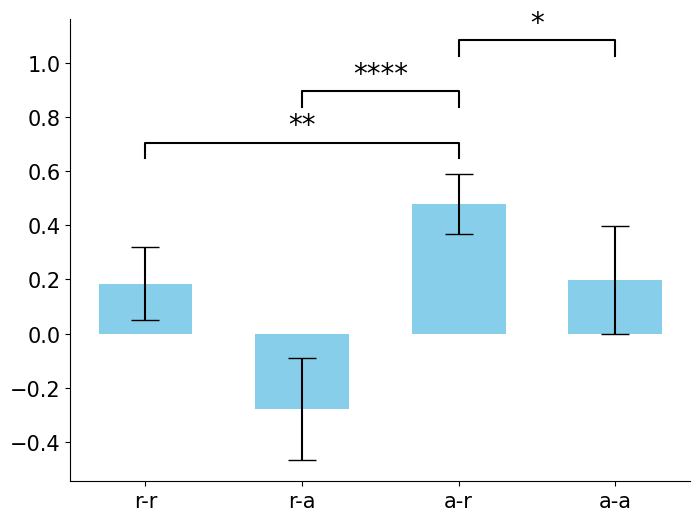

sample number [14, 14, 15, 15]


In [25]:

equal_var=False
fs=15
fs_l=15
comb_li = [date_r_r_max_li, date_r_a_max_li, date_a_r_max_li, date_a_a_max_li]
comb_num = len(comb_li)
each_num = [len(i) for i in comb_li]
labels =["r-r", "r-a", "a-r", "a-a"]
mean_li = [np.mean(i) for i in comb_li]
se_li = [np.std(i)/np.sqrt(len(comb_li)) for i in comb_li]
origin=int(np.argmax(mean_li))
print("max_combi", labels[origin])



d0=comb_li[origin]
tups = []
for i in range(len(comb_li)):
    if i!=origin:
        d1=comb_li[i]
        res=scipy.stats.ttest_ind(d0, d1, 0, equal_var)
        print("{}: {}".format(labels[i], res))
        pstr=eva_pv(res[1])
        tups.append((origin, i, pstr))

bars = np.arange(len(comb_li))

plt.figure(figsize=(8,6))
plt.bar(labels, mean_li, color="skyblue",yerr=se_li, width = 0.6, capsize=10)

annotate_brackets(
    tups, bars, mean_li, 
    yerr=se_li, fs=20
)

plt.ylabel('Pearson\'s correlation with Process S',fontsize = fs)
# plt.xlabel("SD", fontsize = fs)

# plt.hlines(0,0,0.0, 1.2)

# plt.ylim(0.8, 2.0)
# plt.ylim(0,3.5)
plt.xticks(fontsize = fs_l)
plt.yticks(fontsize = fs_l)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.xlabel('',fontsize = fs)
plt.ylabel('', fontsize = fs)
# plt.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False)
# plt.savefig("{}_N{}_r-a_com_0528.SVG".format(model_name,  NE+NI ))
plt.show()

print("sample number", each_num)

In [17]:
#make total files
model_pre = "AN"

op="_net_aup"
model_op = op+"_th0"
bifur = "_nmdar"
lr = "STDP"
lr_p = "a0.7t50th0.6"


dates_means=[]
dates_cvs=[]

fs = 25
nowdir = os.getcwd()
T=300000
sdir=rdir+"/cadyn_rhosw_T{}/".format(T)
N=80

model_name = model_pre + model_op + bifur
combi = "a_r"
savedir = sdir+"{}_{}_N{}_{}_{}/".format(model_name, combi, N,lr,lr_p)



try:
    os.makedirs(savedir)
except FileExistsError:
    print("{} is already exist".format(savedir)) 


savef=savedir + "wake.csv"
savef_s=savedir + "sleep.csv"
savef_cv=savedir + "wake_cv.csv"
savef_cv_s=savedir + "sleep_cv.csv"

c=0
for n, path in enumerate(date_a_r_max_paths):
#     if n>0:
#         continue
    rho_cal_dir = ("_").join(path.split("_")[0:45])+"_"

    if not os.path.exists(rho_cal_dir+"rhosw.npy"):
        continue
    if not os.path.exists(rho_cal_dir+"cvsw.npy"):
        continue
        
        
        
    effis = np.load(rho_cal_dir+"rhosw.npy")
    print("{}: {}".format(n, effis))
    
    if effis[0]==0 or effis[1]==0:
        continue
    
    effis_w = np.array([n, effis[1]])
    effis_s = np.array([n, effis[0]])
    #wake
    if not os.path.exists(savef):
        np.savetxt(savef, effis_w, delimiter=',')
    elif c==0 and os.path.exists(savef):
        np.savetxt(savef, effis_w, delimiter=',')  #create new file 

    elif c!=0 and os.path.exists(savef):
        pre =  np.genfromtxt(savef, delimiter=',', dtype=np.float64)
        total =np.vstack([pre, effis_w])
        print(total)
        np.savetxt(savef, total, delimiter=',')
        
    dates_means.append(path.split("/")[3])
    
    
    #sleep
    if not os.path.exists(savef_s):
        np.savetxt(savef_s, effis_s, delimiter=',')
    elif c==0 and os.path.exists(savef_s):
        np.savetxt(savef_s, effis_s, delimiter=',')  #create new file 

    elif c!=0 and os.path.exists(savef_s):
        pre =  np.genfromtxt(savef_s, delimiter=',', dtype=np.float64)
        total =np.vstack([pre, effis_s])
        print(total)
        np.savetxt(savef_s, total, delimiter=',')
        
        
        
    #cv
    if not os.path.exists(rho_cal_dir+"cvsw.npy"):
#         print("{} not found".format(rho_cal_dir+"cvsw.npy"))
        continue
    effis = np.load(rho_cal_dir+"cvsw.npy")
#     if effis[0]==0 or effis[1]==0:
#         continue
    
    effis_w = np.array([n, effis[1]])
    effis_s = np.array([n, effis[0]])
    #wake
    if not os.path.exists(savef_cv):
        np.savetxt(savef_cv, effis_w, delimiter=',')
    elif c==0 and os.path.exists(savef):
        np.savetxt(savef_cv, effis_w, delimiter=',')  #create new file 

    elif c!=0 and os.path.exists(savef_cv):
        pre =  np.genfromtxt(savef_cv, delimiter=',', dtype=np.float64)
        total =np.vstack([pre, effis_w])
#         print(total)
        np.savetxt(savef_cv, total, delimiter=',')
    dates_cvs.append(path.split("/")[3])
    
    #sleep
    if not os.path.exists(savef_cv_s):
        np.savetxt(savef_cv_s, effis_s, delimiter=',')
    elif c==0 and os.path.exists(savef_s):
        np.savetxt(savef_cv_s, effis_s, delimiter=',')  #create new file 

    elif c!=0 and os.path.exists(savef_cv_s):
        pre =  np.genfromtxt(savef_cv_s, delimiter=',', dtype=np.float64)
        total =np.vstack([pre, effis_s])
#         print(total)
        np.savetxt(savef_cv_s, total, delimiter=',')
    
#     dates_rho.append(date_i)
    
    c +=1
    
    

./cadyn_rhosw_T300000/SANAGNca_NaK1_log_cadyn_aeva3_syn_th0_nmdar_a_r_N80_STDP_a0.7t50th0.6/ is already exist
0: [0.6915833  0.59049606]
1: [0.78870807 0.73210199]
[[0.         0.59049606]
 [1.         0.73210199]]
[[0.         0.6915833 ]
 [1.         0.78870807]]
2: [0.60596652 0.55854626]
[[0.         0.59049606]
 [1.         0.73210199]
 [2.         0.55854626]]
[[0.         0.6915833 ]
 [1.         0.78870807]
 [2.         0.60596652]]
3: [0.74090509 0.63826923]
[[0.         0.59049606]
 [1.         0.73210199]
 [2.         0.55854626]
 [3.         0.63826923]]
[[0.         0.6915833 ]
 [1.         0.78870807]
 [2.         0.60596652]
 [3.         0.74090509]]
4: [0.69242269 0.57497214]
[[0.         0.59049606]
 [1.         0.73210199]
 [2.         0.55854626]
 [3.         0.63826923]
 [4.         0.57497214]]
[[0.         0.6915833 ]
 [1.         0.78870807]
 [2.         0.60596652]
 [3.         0.74090509]
 [4.         0.69242269]]
5: [0.77596818 0.60798596]
[[0.         0.59049

19: [0.85434645 0.69239369]
[[ 0.          0.59049606]
 [ 1.          0.73210199]
 [ 2.          0.55854626]
 [ 3.          0.63826923]
 [ 4.          0.57497214]
 [ 5.          0.60798596]
 [ 6.          0.51971953]
 [ 7.          0.61965798]
 [ 8.          0.70128873]
 [ 9.          0.70016948]
 [10.          0.56322358]
 [11.          0.73228594]
 [12.          0.54610012]
 [13.          0.55220928]
 [14.          0.71366698]
 [15.          0.56293174]
 [16.          0.70291638]
 [17.          0.77605593]
 [18.          0.57079813]
 [19.          0.69239369]]
[[ 0.          0.6915833 ]
 [ 1.          0.78870807]
 [ 2.          0.60596652]
 [ 3.          0.74090509]
 [ 4.          0.69242269]
 [ 5.          0.77596818]
 [ 6.          0.54769955]
 [ 7.          0.65640041]
 [ 8.          0.75410692]
 [ 9.          0.7371331 ]
 [10.          0.60238857]
 [11.          0.8268495 ]
 [12.          0.58992721]
 [13.          0.65657095]
 [14.          0.79267164]
 [15.          0.59526962]

In [ ]:
#comparing mean efficacy
import seaborn as sns
from statannot import add_stat_annotation

model_pre = "AN"
op="_net_aup"
model_op = op+"_th0"
bifur = "_nmdar"
lr = "STDP"
lr_p = "a0.7t50th0.6"


N=80

T=300000
sdir=rdir + "/cadyn_rhosw_T{}/".format(T)


try:
    os.makedirs(sdir)
except FileExistsError:
    print("{} is already exist".format(sdir)) 
    
model_name = model_pre + model_op + bifur
combi = "a_r"  #
savedir = sdir+"{}_{}_N{}_{}_{}/".format(model_name, combi, N,lr,lr_p)


lr_li =[lr] # ["Hebbian", "Anti-Hebbian", "STDP", "Anti-STDP"]
sw = ["sleep", "wake"]
fs = 18
fs_l = 15
Hz="4.0"

colors =[sns.xkcd_rgb["magenta"]]
# plt.figure(figsize=(24,15))


for m, lr in enumerate(lr_li):
    
    dsb_w = savedir + "wake.csv"
    dsb_s = savedir+"sleep.csv"
    synv_w= np.genfromtxt(dsb_w, delimiter=",", dtype=np.float64)
    print(lr, "wake", len(synv_w), np.mean(synv_w,axis = 0))
    synv_s= np.genfromtxt(dsb_s, delimiter=",", dtype=np.float64)
    print(lr,  "sleep", len(synv_s), np.mean(synv_s,axis = 0))

    df_w = pd.DataFrame(synv_w, columns=["order","mean_effi"])
    df_s = pd.DataFrame(synv_s, columns=["order","mean_effi"])
    df_w["lr"] = lr
    df_s["lr"] = lr
    df_w["state"] = "wake"
    df_s["state"] = "sleep"
    
    df_s["Hz"] = Hz
    df_w["Hz"] = Hz
    

    dfs = pd.concat([df_s, df_w])
    print(dfs)

    plt.figure(figsize=(10,10))
    
    x = "Hz"
    y = "mean_effi"
    hue = "state"
    hue_order = sw
    ax = sns.boxplot(data=dfs,palette=[colors[m], sns.xkcd_rgb["white"]], x=x, y=y, hue=hue)
    add_stat_annotation(ax, data=dfs, x=x, y=y, hue=hue,comparisons_correction=None,

                                         box_pairs = [(('4.0',"sleep"), ('4.0', "wake"))
                                                     ],
                                       
                        test='t-test_ind', text_format='star', loc='outside', fontsize=fs, verbose=2)
 
    plt.yticks(fontsize = fs_l)
    plt.xticks(fontsize = fs_l)
    ax.set_yticks(np.arange(0,1.1,0.25))
    ax.set_ylim(0, 1.05)

    plt.ylabel("Mean synaptic efficacy", fontsize = fs)
    plt.xlabel("", fontsize = fs)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.grid(False)
   
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=fs_l)
    plt.tight_layout()
    

    plt.savefig("boxplot_{}_N{}_{}_{}_T{}.SVG".format(model_name, N, lr, lr_p,T))
    plt.show()

In [ ]:
#comparing mean efficacy  CV
import seaborn as sns
from statannot import add_stat_annotation

model_pre = "AN"
op="_net_aup"
model_op = op+"_th0"
bifur = "_nmdar"
lr = "STDP"
lr_p = "a0.7t50th0.6"


N=80

T=300000
sdir=rdir + "/cadyn_rhosw_T{}/".format(T)


try:
    os.makedirs(sdir)
except FileExistsError:
    print("{} is already exist".format(sdir)) 
    
model_name = model_pre + model_op + bifur
combi = "a_r"  #
savedir = sdir+"{}_{}_N{}_{}_{}/".format(model_name, combi, N,lr,lr_p)


lr_li =[lr] # ["Hebbian", "Anti-Hebbian", "STDP", "Anti-STDP"]
sw = ["sleep", "wake"]
fs = 18
fs_l = 15
Hz="4.0"

colors =[sns.xkcd_rgb["magenta"]]
# plt.figure(figsize=(24,15))


for m, lr in enumerate(lr_li):
    
    dsb_w = savedir + "wake_cv.csv"
    dsb_s = savedir+"sleep_cv.csv"
    synv_w= np.genfromtxt(dsb_w, delimiter=",", dtype=np.float64)
    print(lr, "wake", len(synv_w), np.mean(synv_w,axis = 0))
    synv_s= np.genfromtxt(dsb_s, delimiter=",", dtype=np.float64)
    print(lr,  "sleep", len(synv_s), np.mean(synv_s,axis = 0))

    df_w = pd.DataFrame(synv_w, columns=["order","CV"])
    df_s = pd.DataFrame(synv_s, columns=["order","CV"])
    df_w["lr"] = lr
    df_s["lr"] = lr
    df_w["state"] = "wake"
    df_s["state"] = "sleep"
    
    df_s["Hz"] = Hz
    df_w["Hz"] = Hz
    

    dfs = pd.concat([df_s, df_w])
    print(dfs)

    plt.figure(figsize=(10,10))
    
    x = "Hz"
    y = "CV"
    hue = "state"
    hue_order = sw
    ax = sns.boxplot(data=dfs,palette=[colors[m], sns.xkcd_rgb["white"]], x=x, y=y, hue=hue)
    add_stat_annotation(ax, data=dfs, x=x, y=y, hue=hue,comparisons_correction=None,

                                         box_pairs = [(('4.0',"sleep"), ('4.0', "wake"))
                                                     ],
                                       
                        test='t-test_ind', text_format='star', loc='outside', fontsize=fs, verbose=2)
 
    plt.yticks(fontsize = fs_l)
    plt.xticks(fontsize = fs_l)
    ax.set_yticks(np.arange(0,1.1,0.25))
    ax.set_ylim(0, 1.05)

    plt.ylabel("Mean synaptic efficacy", fontsize = fs)
    plt.xlabel("", fontsize = fs)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.grid(False)
   
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=fs_l)
    plt.tight_layout()
    

    plt.savefig("boxplot_{}_N{}_{}_{}_T{}_CV.SVG".format(model_name, N, lr, lr_p,T))
    plt.show()